____
# Closure at different depth


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss3e3', 'swot250gauss4e3', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss3e3', 'swot2kmgauss4e3', 'swot2kmgauss5e3', 'swot2kmgauss1e4']),
 dict_keys(['era5']))

In [3]:
def compute_mean_square(ds):
    var = ['acc', 'cor', 'ggd', 'wd','sum']
    VAR = ['ACC', 'COR', 'GGD', 'WD', 'S']
    dss = (ds[[v+'n' for v in var] + [v+'e' for v in var]]**2).mean(dim='row_number').rename({var[i]+'n' : VAR[i]+'n' for i in range(5)}).rename({var[i]+'e' : VAR[i]+'e' for i in range(5)})
    dss['sigmae'] = dss.ACCe + dss.CORe + dss.GGDe + dss.WDe
    dss['sigman'] = dss.ACCn + dss.CORn + dss.GGDn + dss.WDn
    dss['nb_coloc'] = len(ds.row_number)
    #Balanced and error
    for direction in ['e', 'n']:
        for v in ['acc', 'cor', 'ggd', 'wd'] : 
                dss['B'+direction+'_'+v] = -((ds[v+direction]*ds['exc'+direction+'_'+v])).mean(dim='row_number')
                dss['E'+direction+'_'+v] = ((ds[v+direction]*ds['sum'+direction])).mean(dim='row_number')
    #pairs contributions
    for v in [v for v in ds if 'prod' in v]:
        dss[v.replace('prod', 'X')]=-2*ds[v].mean(dim='row_number')
    return dss

_______
# Count 

In [30]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15'),]

DS = dataset_coloc_combs(comb_list, nearest =False).dropna('row_number').drop_sel(row_number = err_acc)
DSS = DS.where(DS.depth==0, drop=True)
DSD = DS.where(DS.depth==15, drop=True)
DS50 = DS.where(DS.depth==50, drop=True)
DS100 = DS.where(DS.depth==100, drop=True)

dfs = (compute_mean_square(DSS)/U2).to_dataframe()
dfd =( compute_mean_square(DSD)/U2).to_dataframe()
df50 = (compute_mean_square(DS50)/U2).to_dataframe()
df100 = (compute_mean_square(DS100)/U2).to_dataframe()

df = pd.concat([dfs.iloc[0], dfd.iloc[1], df50.iloc[1], df100.iloc[1]], axis=1).transpose()
df['depth'] = np.array([0, 15, 50, 100])
df = df.reset_index().rename(columns ={'index':'id_comb'}).set_index('depth')
df

nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot2kmnaive_etaf__rio_15era5


,id_comb,ACCn,CORn,GGDn,WDn,Sn,ACCe,CORe,GGDe,WDe,...,Xe_acc_wd,Xe_cor_ggd,Xe_cor_wd,Xe_ggd_wd,Xn_acc_cor,Xn_acc_ggd,Xn_acc_wd,Xn_cor_ggd,Xn_cor_wd,Xn_ggd_wd
depth,,,,,,,,,,,,,,,,,,,,,
0,nofilter__swot2kmnaive_etaf__rio_0era5,2.208146,3.800721,1.715636,0.048334,1.758459,1.990658,3.873232,1.357567,0.278156,...,-0.091789,1.722060,1.096115,-0.091863,3.359300,-0.083320,-0.053536,2.491183,0.267394,0.033357
15,nofilter__swot2kmnaive_etaf__rio_15era5,1.205329,2.741469,1.739965,0.005280,1.293271,1.177184,2.346623,1.346890,0.041782,...,-0.022458,1.818551,0.164570,0.009678,2.029843,-0.183575,-0.010597,2.497900,0.045817,0.019385
50,nofilter__swot2kmnaive_etaf__rio_15era5,0.358854,1.856172,3.094370,0.005329,1.618148,0.359361,2.636360,3.502290,0.023527,...,-0.008128,4.739184,0.050600,-0.013006,0.669865,-0.132930,-0.004258,3.156308,0.010144,-0.002551
100,nofilter__swot2kmnaive_etaf__rio_15era5,0.200307,0.723427,1.039018,0.003124,0.650912,0.213444,0.687816,1.363328,0.068056,...,0.011355,0.821088,0.005854,0.054320,0.437349,-0.053053,-0.005576,0.901418,0.012471,0.022355


7.499612659773717
7.910181989423267
7.772837093870806
7.987421849104917
4.912479468447006
5.139451708676717
5.692042490712779
5.9431349311883235
6.521538055410622
6.6078868687805645
5.314726257547904
5.507612784254508
2.332644009719507
2.4140803456834834
1.965875513903089
2.0441637571174995


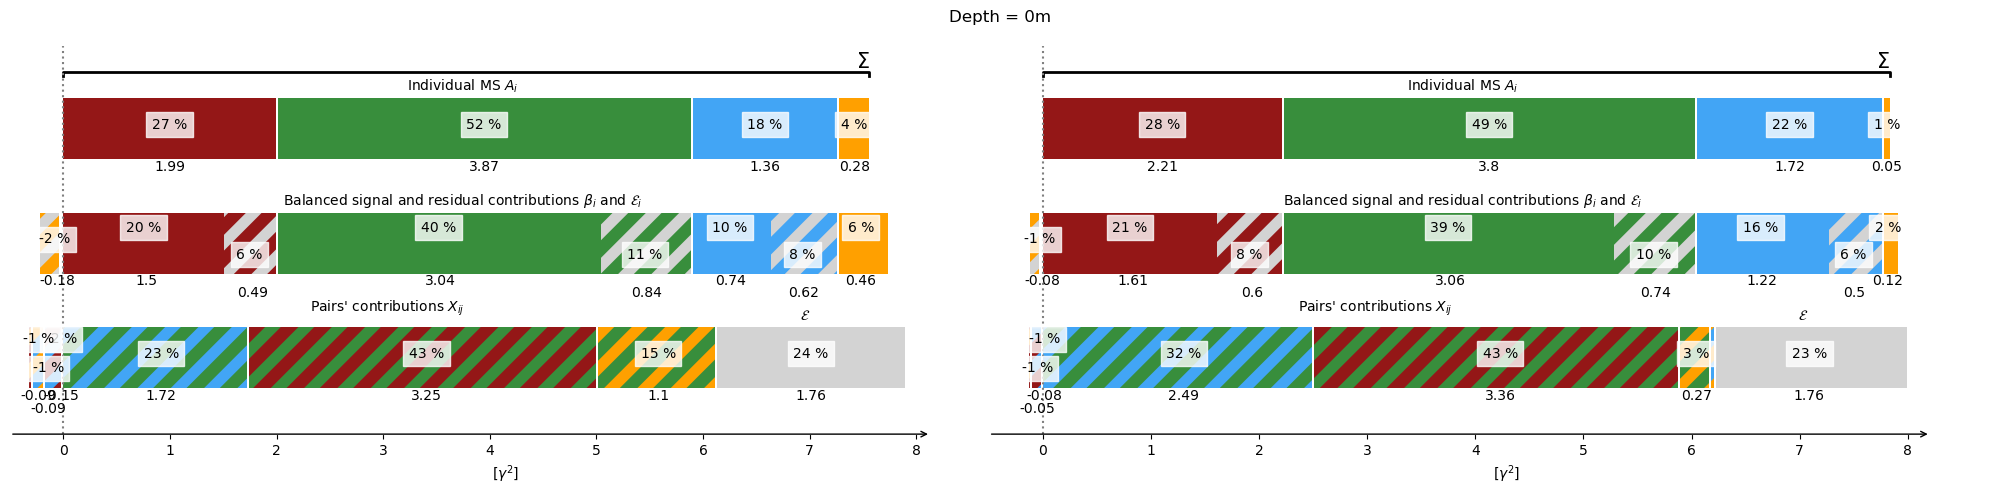

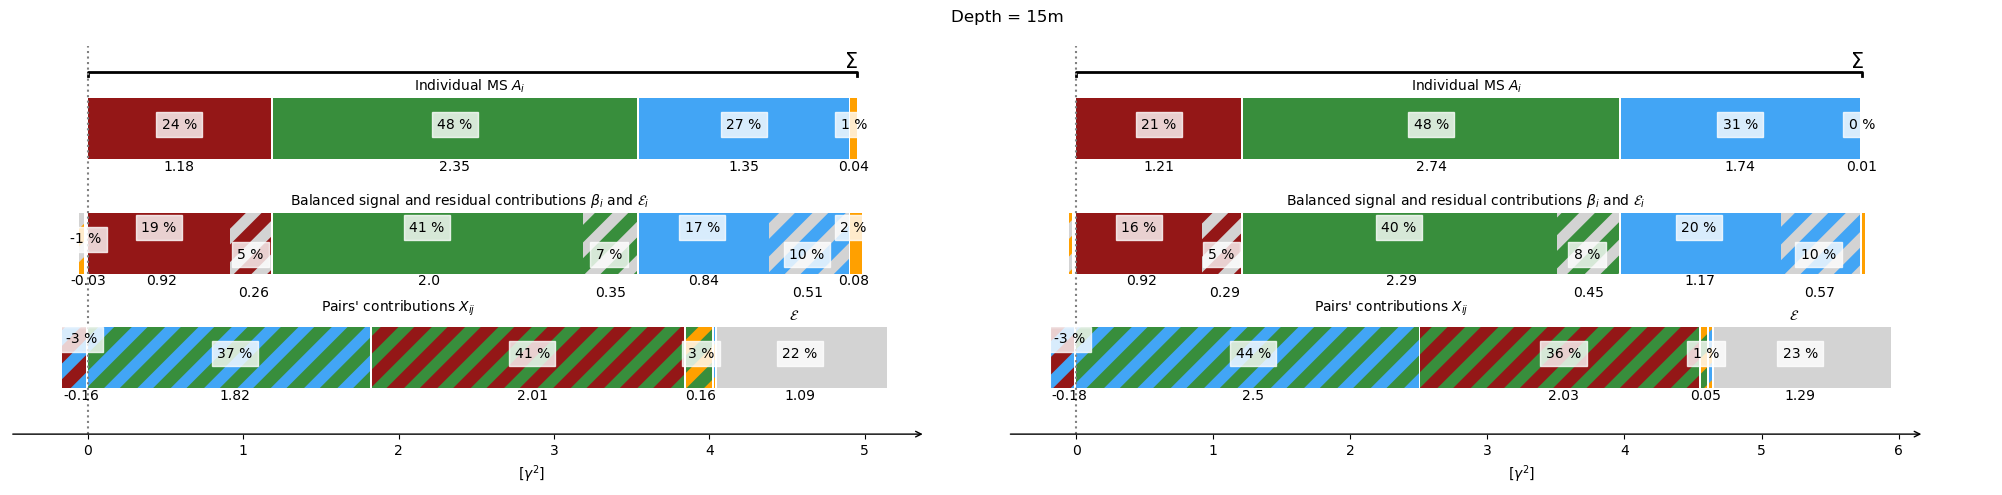

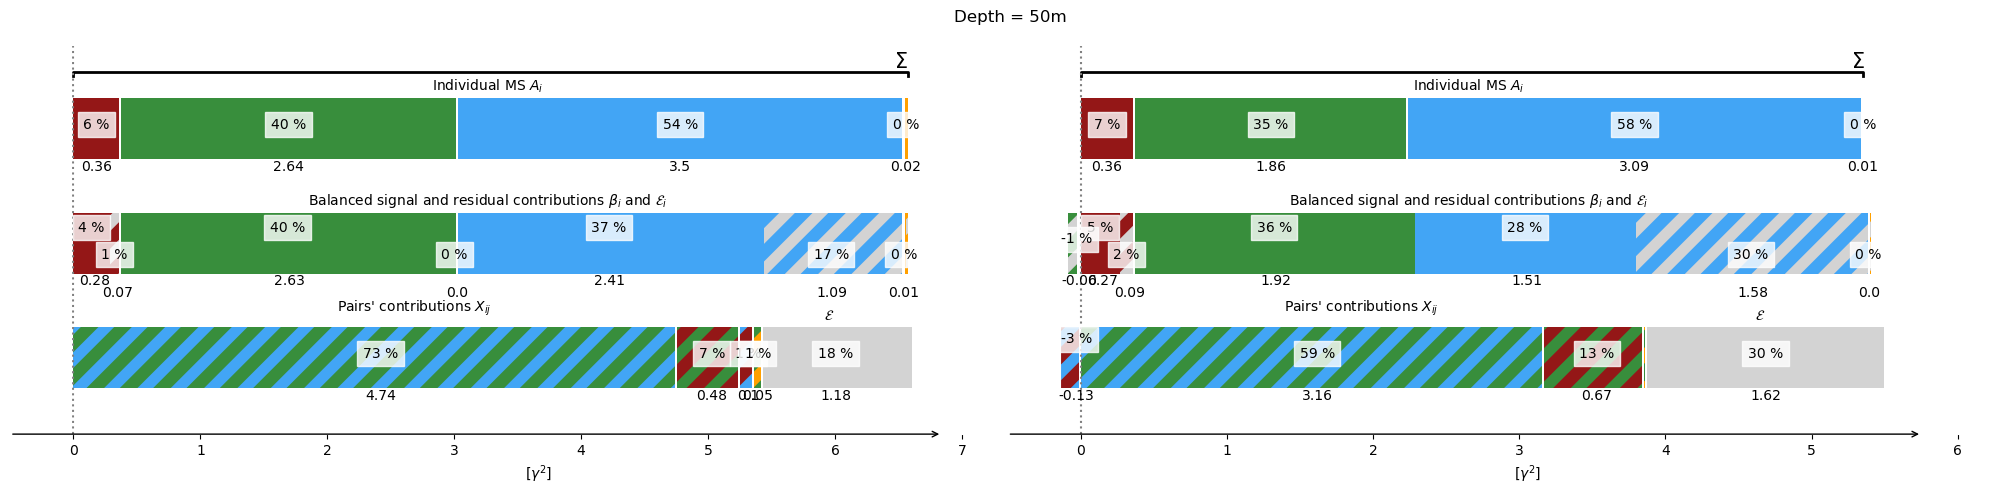

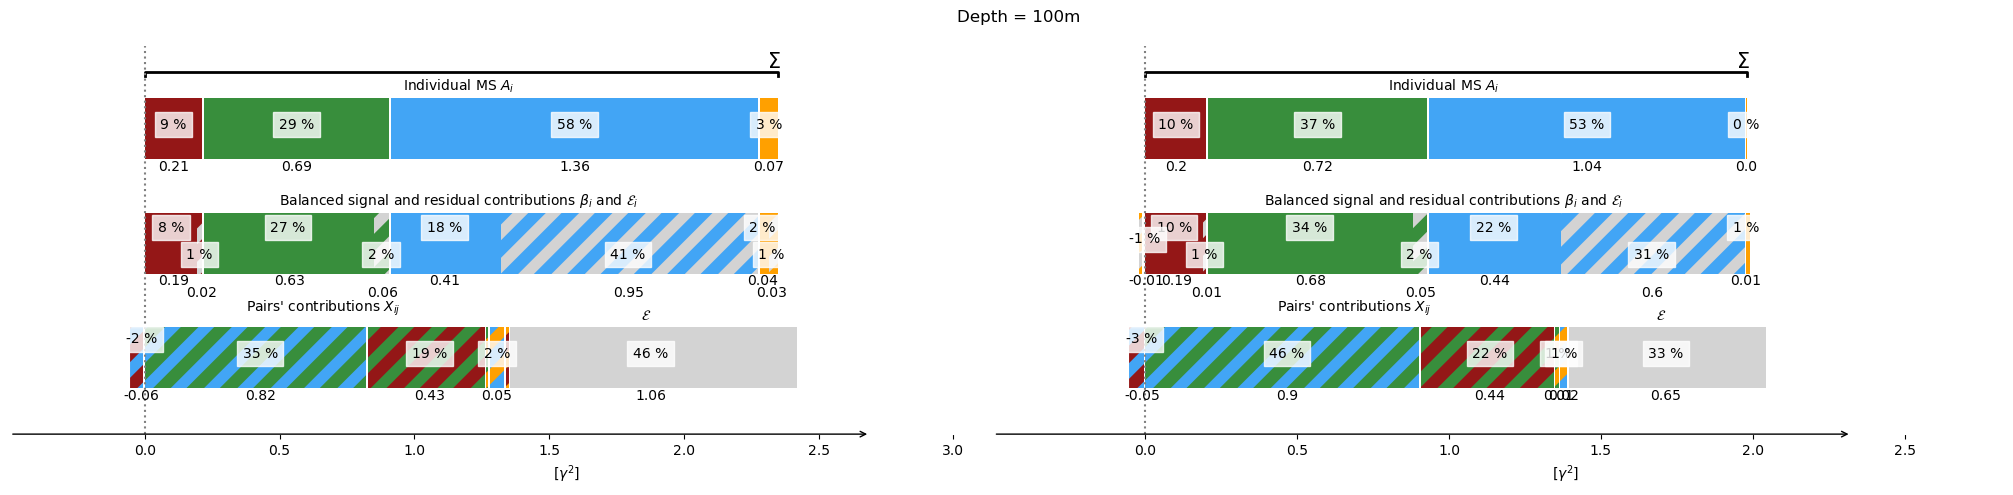

In [34]:
for c in [0, 15, 50, 100] :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e')
    synthetic_figure(df.loc[c], axs[1], dir='n')
    fig.suptitle(f'Depth = {c}m')
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', f'depth_{c}.png'))